In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
print(f"Project root: {project_root.resolve()}")
print(f"Working dir:  {Path.cwd().resolve()}")

Project root: C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn
Working dir:  C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\notebooks


In [2]:
import warnings
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from src.config_loader import load_config
from src.data_loader import load_data

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
config_path = project_root / "config" / "default.yaml"
config = load_config(str(config_path))

print(f"Experiment: {config['experiment']['name']}")
print(f"Seed: {config['experiment']['seed']}")
print()

train_path = Path(config["data"]["train_path"])
test_path = Path(config["data"]["test_path"])
target_col = config["data"]["target_column"]
id_col = config["data"]["id_column"]

if not train_path.is_absolute():
    train_path = project_root / train_path
if not test_path.is_absolute():
    test_path = project_root / test_path

train_df = load_data(str(train_path))
test_df = load_data(str(test_path))

if target_col not in train_df.columns:
    case_insensitive_match = [col for col in train_df.columns if col.lower() == target_col.lower()]
    if case_insensitive_match:
        target_col = case_insensitive_match[0]
    elif "Churn" in train_df.columns:
        target_col = "Churn"

print(f"Resolved target column: {target_col}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Experiment: default
Seed: 42

Resolved target column: Churn
Train shape: (594194, 21)
Test shape:  (254655, 20)


In [4]:
if target_col not in train_df.columns:
    raise ValueError(f"Target column '{target_col}' not found in training data")

y_raw = train_df[target_col].copy()
X = train_df.drop(columns=[target_col]).copy()
X_test = test_df.copy()

if id_col and id_col in X.columns:
    X = X.drop(columns=[id_col])
if id_col and id_col in X_test.columns:
    X_test = X_test.drop(columns=[id_col])

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Target classes: {list(target_encoder.classes_)}")

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numerical_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target classes: ['No', 'Yes']


In [5]:
SEED = int(config["experiment"]["seed"])
N_SPLITS = 5
N_TRIALS = 50
TIMEOUT_SECONDS = None  # contoh: 1800 untuk batas 30 menit

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

positive_ratio = float(np.mean(y))
negative_ratio = 1.0 - positive_ratio
scale_pos_weight = (negative_ratio / positive_ratio) if positive_ratio > 0 else 1.0

print(f"CV folds: {N_SPLITS}")
print(f"Optuna trials: {N_TRIALS}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

CV folds: 5
Optuna trials: 50
scale_pos_weight: 3.4403


In [6]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 15.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        **params,
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    fold_scores = []
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y[train_idx]
        X_valid_fold = X.iloc[valid_idx]
        y_valid_fold = y[valid_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        valid_proba = pipeline.predict_proba(X_valid_fold)[:, 1]
        fold_auc = roc_auc_score(y_valid_fold, valid_proba)
        fold_scores.append(fold_auc)

        trial.report(fold_auc, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

In [7]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name=f"xgboost_optuna_{config['experiment']['name']}",
)

study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SECONDS, show_progress_bar=True)

print("\nBest ROC-AUC:", study.best_value)
print("Best Params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

optuna_df = study.trials_dataframe()
display(optuna_df.sort_values("value", ascending=False).head(10))

[I 2026-03-23 20:18:07,750] A new study created in memory with name: xgboost_optuna_default


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-23 20:19:00,630] Trial 0 finished with value: 0.9123140866788315 and parameters: {'n_estimators': 574, 'learning_rate': 0.1540359659501924, 'max_depth': 8, 'min_child_weight': 9.381218778758512, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 3.200866785899844e-08, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.9123140866788315.
[I 2026-03-23 20:21:12,772] Trial 1 finished with value: 0.9135398543299159 and parameters: {'n_estimators': 908, 'learning_rate': 0.0011152328125494347, 'max_depth': 10, 'min_child_weight': 12.654196971205904, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 3.939402261362697e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 1 with value: 0.9135398543299159.
[I 2026-03-23 20:22:18,765] Trial 2 finished with value: 0.9133573657296614 and parameters: {'n_estimators': 632, 'learning_rate': 0.004

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
43,43,0.917368,2026-03-23 20:53:06.906845,2026-03-23 20:53:33.618810,0 days 00:00:26.711965,0.761224,3.091331e-07,0.075210,5,3.141381,425,9.057362e-04,8.345286e-06,0.782093,PRUNED
20,20,0.916976,2026-03-23 20:38:34.308643,2026-03-23 20:39:32.363164,0 days 00:00:58.054521,0.794972,8.145964e-02,0.015542,6,4.764236,947,1.272297e-08,4.755272e-02,0.866110,PRUNED
39,39,0.916889,2026-03-23 20:50:30.791235,2026-03-23 20:50:58.124697,0 days 00:00:27.333462,0.601409,1.222679e-07,0.089186,4,5.563498,1148,2.554482e-02,4.694292e-04,0.638830,PRUNED
33,33,0.916837,2026-03-23 20:47:37.654691,2026-03-23 20:47:57.911526,0 days 00:00:20.256835,0.653507,5.460568e-08,0.084123,3,6.813905,1010,2.645938e-03,2.495347e-04,0.795521,PRUNED
34,34,0.916837,2026-03-23 20:47:57.913570,2026-03-23 20:48:22.421323,0 days 00:00:24.507753,0.679738,3.896400e-07,0.129097,4,8.757538,1115,1.887318e-02,1.181027e-03,0.743655,PRUNED
44,44,0.916833,2026-03-23 20:53:33.620787,2026-03-23 20:53:59.373092,0 days 00:00:25.752305,0.789830,1.221297e-04,0.033822,4,11.040765,1158,4.229173e-02,2.398513e-01,0.892799,PRUNED
45,45,0.916796,2026-03-23 20:53:59.375343,2026-03-23 20:54:29.066605,0 days 00:00:29.691262,0.746368,5.989527e-06,0.020979,5,4.078781,1200,3.087822e-01,4.999921e-05,0.761255,PRUNED
27,27,0.916738,2026-03-23 20:43:42.547617,2026-03-23 20:44:01.274799,0 days 00:00:18.727182,0.834327,9.711767e-05,0.044739,4,7.683153,750,2.450742e-05,6.755299e-02,0.859793,PRUNED
24,24,0.916592,2026-03-23 20:42:30.604311,2026-03-23 20:42:55.480912,0 days 00:00:24.876601,0.986581,1.189012e-03,0.056457,6,4.802188,930,6.905692e-07,2.499496e-08,0.910922,PRUNED
35,35,0.916552,2026-03-23 20:48:22.423538,2026-03-23 20:48:41.315270,0 days 00:00:18.891732,0.655359,1.313241e-07,0.058832,3,10.272353,916,5.390611e-03,9.608193e-05,0.886207,PRUNED


In [8]:
best_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    **study.best_params,
    )

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model),
])

cv_scores = cross_val_score(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    )

print(f"Final CV ROC-AUC: {cv_scores.mean():.5f} +- {cv_scores.std():.5f}")

final_pipeline.fit(X, y)

Final CV ROC-AUC: 0.91645 +- 0.00092


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


,Feature,Importance
36,Contract_Month-to-month,0.471948
16,InternetService_Fiber optic,0.252480
18,OnlineSecurity_No,0.081415
43,PaymentMethod_Electronic check,0.055599
27,TechSupport_No,0.020007
37,Contract_One year,0.011051
32,StreamingTV_Yes,0.010901
39,PaperlessBilling_No,0.010423
38,Contract_Two year,0.009862
35,StreamingMovies_Yes,0.008188


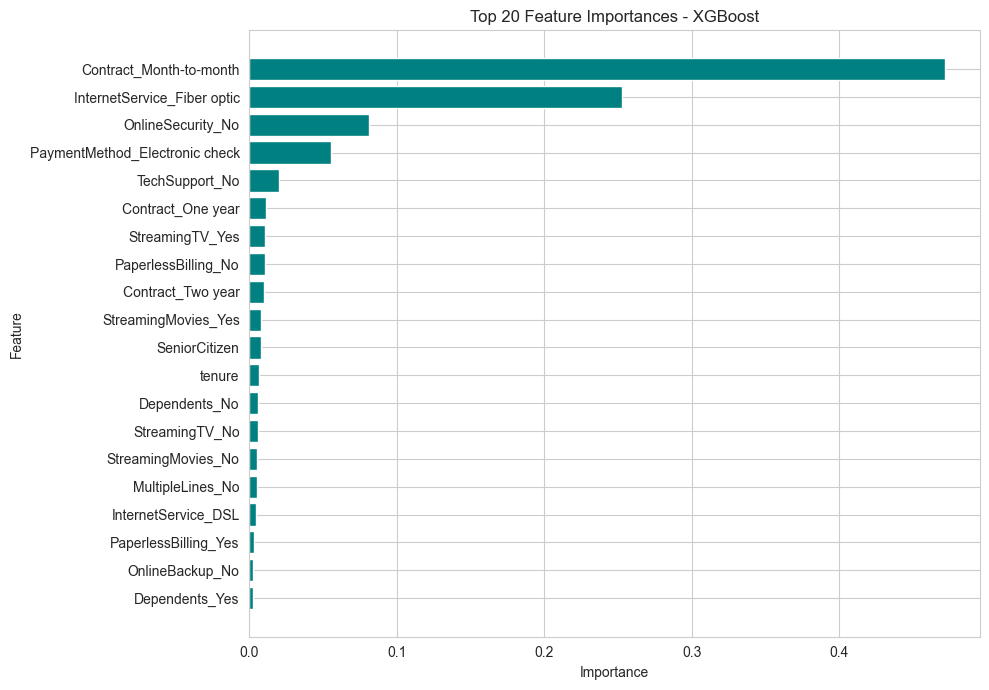

In [9]:
# Build feature name list after fitting preprocessor
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_model = final_pipeline.named_steps["model"]

feature_names = []
if len(numerical_features) > 0:
    feature_names.extend(numerical_features)

if len(categorical_features) > 0:
    cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
    onehot = cat_pipeline.named_steps["onehot"]
    cat_feature_names = onehot.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_feature_names)

importances = fitted_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
top_k = importance_df.head(20).sort_values("Importance", ascending=True)
plt.barh(top_k["Feature"], top_k["Importance"], color="teal")
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [10]:
test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_pred_encoded = (test_proba >= 0.5).astype(int)
test_pred_labels = target_encoder.inverse_transform(test_pred_encoded)

sample_submission_path = project_root / "data" / "raw" / "sample_submission.csv"
output_submission_path = project_root / config["output"]["submission_path"]
output_submission_path.parent.mkdir(parents=True, exist_ok=True)

if sample_submission_path.exists():
    submission = pd.read_csv(sample_submission_path)
    candidate_target_cols = [c for c in submission.columns if c.lower() not in {"id", str(id_col).lower()}]
    if not candidate_target_cols:
        raise ValueError("Could not determine target column in sample submission")
    submission_target_col = candidate_target_cols[0]

    if pd.api.types.is_numeric_dtype(submission[submission_target_col]):
        submission[submission_target_col] = test_pred_encoded
    else:
        submission[submission_target_col] = test_pred_labels

    if id_col and id_col in submission.columns and id_col in test_df.columns:
        submission[id_col] = test_df[id_col].values
else:
    submission_target_col = target_col
    if id_col and id_col in test_df.columns:
        submission = pd.DataFrame({
            id_col: test_df[id_col].values,
            submission_target_col: test_pred_encoded,
        })
    else:
        submission = pd.DataFrame({submission_target_col: test_pred_encoded})

submission.to_csv(output_submission_path, index=False)
display(submission.head())
print(f"Submission saved to: {output_submission_path}")

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,1


Submission saved to: c:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\experiments\default\submission.csv


In [11]:
best_params_path = output_submission_path.parent / "xgb_optuna_best_params.yaml"
best_params_payload = {
    "best_value_roc_auc": float(study.best_value),
    "best_params": study.best_params,
    "n_trials": len(study.trials),
    "cv_folds": N_SPLITS,
    "target_column": target_col,
}

import yaml
with open(best_params_path, "w", encoding="utf-8") as f:
    yaml.dump(best_params_payload, f, sort_keys=False)

print(f"Best params saved to: {best_params_path}")

Best params saved to: c:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\experiments\default\xgb_optuna_best_params.yaml
